## 1. Importación de librerías

Se importan las herramientas necesarias para cargar imágenes, crear los conjuntos de datos, entrenar el modelo y mostrar los resultados.

- `torch`: permite trabajar con tensores y realizar las operaciones del perceptrón.
- `ImageFolder`: carga imágenes organizadas en carpetas por clase.
- `DataLoader`: permite recorrer las imágenes durante el entrenamiento y la prueba.
- `transforms`: transforma las imágenes a escala de grises y tensores.
- `matplotlib`: permite mostrar las imágenes y los mapas de calor.

In [438]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [439]:
class perceptron():
    def __init__(self,n_inputs,n_outputs):
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.threshold = 0
        self.weights = []
        for i in range(self.n_outputs):
            self.weights.append(torch.zeros(n_inputs+1,1,dtype = torch.float32))
            
    def forward(self,x):
        output = []
        for i in range(self.n_outputs):
            if torch.matmul(x,self.weights[i])>self.threshold:
                output_prev = 1
            elif torch.matmul(x,self.weights[i])<-self.threshold:
                output_prev = -1
            else:
                output_prev = 0
            output.append(output_prev)
        return torch.tensor(output)

    def train(self,traindataloader,learning_rate=1, threshold=1):
        self.learning_rate = learning_rate
        self.threshold = threshold
        stop_condition = False
        epochs = 0
        while not(stop_condition):
            print('epochs', epochs)
            stop_condition = True
            for img, labels in iter(traindataloader):
                img_b = 2*((img>0.5)*1.0)-1
                t = torch.tensor([-1,-1,-1])
                x_i = torch.concat([torch.ones(1), img_b.flatten()]).unsqueeze(axis=0)
                t[labels.item()]=1
                y = self.forward(x_i)
                for i in range(self.n_outputs):
                    if y[i].item()!=t[i].item():
                        self.weights[i][1:] = self.weights[i][1:]+self.learning_rate*(torch.transpose(x_i,0,1)[1:]*t[i])
                        self.weights[i][0] = self.weights[i][0] + self.learning_rate*t[i]
                        stop_condition = False
            epochs+=1

In [440]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [ ]:
train_directory = "dataset_MNO/train/"
test_directory = "dataset_MNO/test/"

In [442]:
transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [443]:
train_dataset = ImageFolder(train_directory,transform_train)
test_dataset = ImageFolder(test_directory,transform_test)

In [444]:
train_dataset.classes

['A', 'B', 'C']

In [445]:
train_dataset.class_to_idx

{'A': 0, 'B': 1, 'C': 2}

In [446]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 30
     Root location: dataset_char_rec/train/
     StandardTransform
 Transform: Compose(
                Grayscale(num_output_channels=1)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 30
     Root location: dataset_char_rec/test/
     StandardTransform
 Transform: Compose(
                Grayscale(num_output_channels=1)
                ToTensor()
            ))

In [447]:
(2*((train_dataset[1][0]>0.5)*1.0)-1)

tensor([[[ 1.,  1., -1., -1.,  1.,  1.,  1.,  1.],
         [ 1., -1., -1., -1.,  1.,  1.,  1.,  1.],
         [ 1., -1.,  1., -1., -1.,  1.,  1.,  1.],
         [ 1., -1.,  1.,  1., -1., -1.,  1.,  1.],
         [ 1., -1.,  1.,  1.,  1., -1.,  1.,  1.],
         [-1., -1., -1., -1., -1., -1., -1.,  1.],
         [-1.,  1.,  1.,  1.,  1.,  1., -1., -1.],
         [-1.,  1.,  1.,  1.,  1.,  1.,  1., -1.]]])

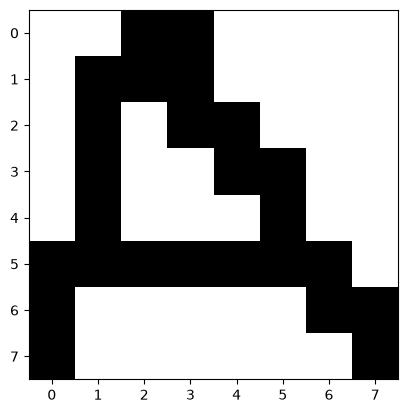

In [448]:
plt.imshow(train_dataset[1][0].permute(dims=[1,2,0]),cmap='gray')
plt.show()

In [449]:
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle = True)
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle = False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x13b79a69710>,
 <torch.utils.data.dataloader.DataLoader at 0x13b7acf4290>)

In [450]:
imgtest = list(iter(train_dataloader))[0][0].squeeze(axis=0)

In [451]:
Perceptron1 = perceptron(n_inputs=64,n_outputs=3)

In [452]:
Perceptron1.train(train_dataloader, learning_rate = 0.01)

epochs 0
epochs 1
epochs 2
epochs 3
epochs 4
epochs 5
epochs 6
epochs 7
epochs 8
epochs 9
epochs 10
epochs 11
epochs 12
epochs 13


In [453]:
indice_clase = 0

Letra seleccionada: A
Salida: tensor([ 0,  0, -1])
Predicción: A


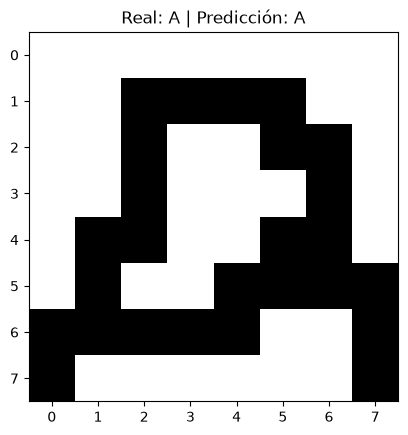

In [454]:
clase = train_dataset.classes[indice_clase]

indices_clase = [
    i
    for i, (_, etiqueta) in enumerate(test_dataset.samples)
    if etiqueta == indice_clase
]

indice = indices_clase[
    torch.randint(0, len(indices_clase), (1,)).item()
]

ruta = test_dataset.samples[indice][0]
real_label = test_dataset.samples[indice][1]

img = plt.imread(ruta)

if img.ndim == 3:
    img = img[:, :, 0]

input = torch.concat([
    torch.ones(1),
    torch.tensor(img).flatten()
]).unsqueeze(axis=0)

input = 2 * ((input > 0.5) * 1.0) - 1

output = Perceptron1.forward(input)

label = train_dataset.classes[torch.argmax(output).item()]

print("Letra seleccionada:", clase)
print("Salida:", output)
print("Predicción:", label)

plt.imshow(img, cmap="gray")
plt.title("Real: " + clase + " | Predicción: " + label)
plt.show()

indice_clase = (indice_clase + 1) % len(test_dataset.classes)

In [455]:
correctas = 0

for img, label in test_dataloader:

    input = torch.concat([
        torch.ones(1),
        img.flatten()
    ]).unsqueeze(axis=0)

    input = 2*((input>0.5)*1.0)-1

    output = Perceptron1.forward(input)

    prediccion = torch.argmax(output).item()

    print(
        "Real:",
        test_dataset.classes[label.item()],
        "| Predicción:",
        test_dataset.classes[prediccion]
    )

    if prediccion == label.item():
        correctas += 1


print("Correctas:", correctas)
print("Total:", len(test_dataset))
print(
    "Exactitud:",
    correctas / len(test_dataset) * 100,
    "%"
)

Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: A
Real: A | Predicción: B
Real: A | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: C
Real: B | Predicción: A
Real: B | Predicción: B
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: A
Real: B | Predicción: B
Real: C | Predicción: C
Real: C | Predicción: C
Real: C | Predicción: A
Real: C | Predicción: C
Real: C | Predicción: A
Real: C | Predicción: C
Real: C | Predicción: C
Real: C | Predicción: C
Real: C | Predicción: C
Real: C | Predicción: A
Correctas: 18
Total: 30
Exactitud: 60.0 %


In [456]:
data = (
    Perceptron1.weights[0][1:]
    + Perceptron1.weights[0][0]
)

minval = min(data)

data = data - minval

maxval = max(data)

if maxval.item() != 0:
    data = data / maxval

data

tensor([[0.6552],
        [0.3448],
        [0.4483],
        [0.4828],
        [0.6552],
        [0.5517],
        [0.7241],
        [0.7241],
        [0.7586],
        [0.4828],
        [0.7586],
        [0.7241],
        [0.9310],
        [0.8276],
        [0.5517],
        [0.7586],
        [0.6897],
        [0.4828],
        [0.4483],
        [0.2414],
        [0.4828],
        [0.5862],
        [0.5862],
        [0.2759],
        [0.4483],
        [0.6552],
        [0.3793],
        [0.7931],
        [0.3448],
        [0.0000],
        [0.1724],
        [0.2414],
        [0.4138],
        [0.8621],
        [0.5517],
        [0.2414],
        [0.1724],
        [0.7241],
        [0.1379],
        [0.3793],
        [0.3103],
        [0.3793],
        [0.2759],
        [0.3448],
        [0.4828],
        [0.6207],
        [0.4138],
        [0.5517],
        [0.5172],
        [0.4138],
        [0.5862],
        [0.4828],
        [0.6552],
        [0.7586],
        [0.3103],
        [0

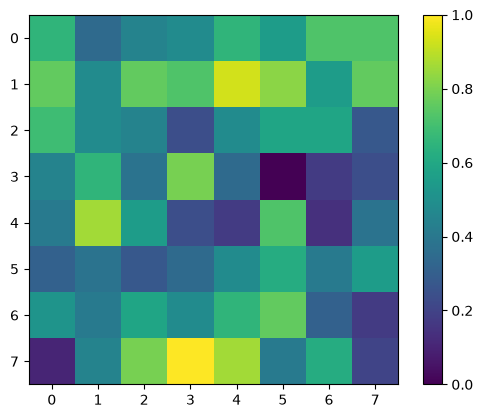

In [457]:
plt.imshow(
    data.reshape((8,8))
)

plt.colorbar()
plt.show()

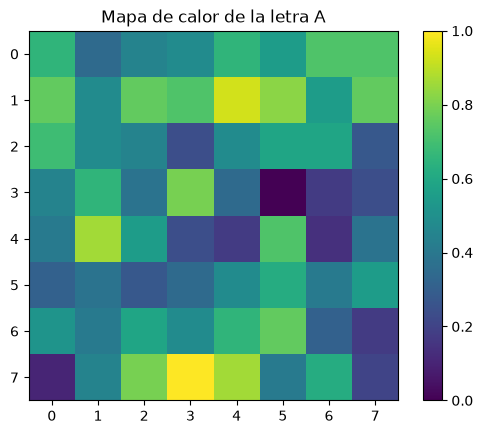

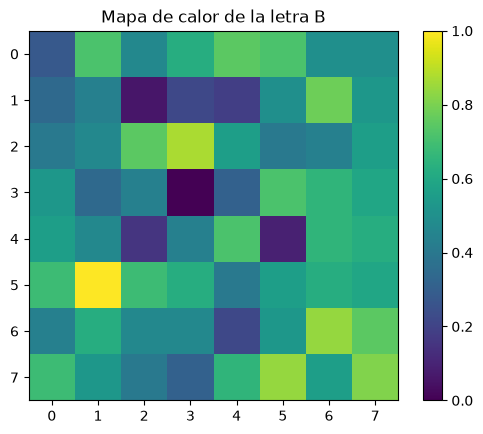

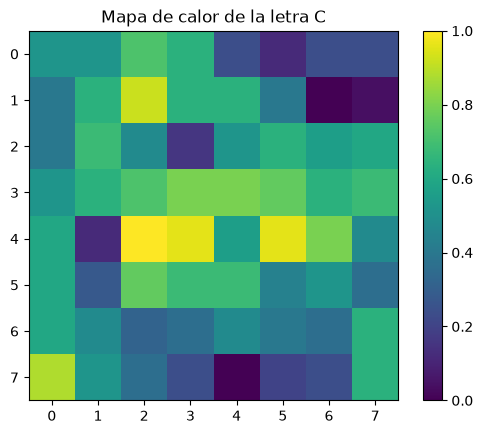

In [458]:
for i in range(3):

    data = (
        Perceptron1.weights[i][1:]
        + Perceptron1.weights[i][0]
    )

    minval = min(data)
    data = data - minval

    maxval = max(data)

    if maxval.item() != 0:
        data = data / maxval

    plt.figure()

    plt.imshow(
        data.reshape(8, 8)
    )

    plt.title(
        "Mapa de calor de la letra "
        + train_dataset.classes[i]
    )

    plt.colorbar()
    plt.show()